# Phase 4.3 — Logistic Slope Sensitivity (b-grid)

Goal:
- Test whether logistic slope b is too steep
- Evaluate mean–risk trade-off across b
- Identify usable parameter region


In [1]:
import os
from pathlib import Path

PROJECT_ROOT = Path("/Users/axl/Mispricing Model_Leviathan/leviathan-model")
os.chdir(PROJECT_ROOT)

print("cwd:", Path.cwd())


cwd: /Users/axl/Mispricing Model_Leviathan/leviathan-model


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SERIES_PATH = "outputs/phase4/series/oos_series.csv"

df = pd.read_csv(SERIES_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

print("Columns:")
print(df.columns.tolist())


Columns:
['date', 'ret_1q_fwd', 'is_oos', 'fragility_score', 'dti_z', 'ms_z', 'exposure_baseline', 'strat_baseline', 'invested_p2', 'strat_p2', 'exposure_linear_clip_k0.30', 'exposure_linear_clip_k0.50', 'exposure_logistic_a0_b1.2', 'exposure_logistic_a0_b1.8', 'strat_linear_clip_k0.30', 'strat_linear_clip_k0.50', 'strat_logistic_a0_b1.2', 'strat_logistic_a0_b1.8']


In [3]:
def logistic(x, a, b):
    return 1.0 / (1.0 + np.exp(-(a + b * x)))


In [5]:
SIGNAL_COL = "fragility_score"  
RET_COL = "ret_1q_fwd"

b_values = [0.5, 0.8, 1.0, 1.2, 1.5, 1.8]

for b in b_values:
    name = f"logistic_b{str(b).replace('.','p')}"
    
    exposure = logistic(df[SIGNAL_COL], 0.0, b)
    
    df[f"exposure_{name}"] = exposure
    df[f"strat_{name}"] = exposure * df[RET_COL]

print("b-grid constructed.")

b-grid constructed.


In [6]:
def summarize(r):
    r = pd.Series(r).dropna()
    return pd.Series({
        "n": r.count(),
        "mean": r.mean(),
        "vol": r.std(),
        "p05": np.percentile(r, 5),
        "min": r.min(),
    })

oos = df["is_oos"].astype(bool)

rows = {}

rows["baseline_full"] = summarize(df.loc[oos, "strat_baseline"])
rows["phase2_gate"] = summarize(df.loc[oos, "strat_p2"])

for b in b_values:
    name = f"logistic_b{str(b).replace('.','p')}"
    rows[name] = summarize(df.loc[oos, f"strat_{name}"])

summary = pd.DataFrame(rows).T
summary


,n,mean,vol,p05,min
baseline_full,55.0,0.010303,0.009649,-0.005537,-0.017667
phase2_gate,55.0,0.009915,0.008974,-0.003971,-0.009567
logistic_b0p5,55.0,0.005548,0.005620,-0.002651,-0.008229
logistic_b0p8,55.0,0.005682,0.006026,-0.002968,-0.007869
logistic_b1p0,55.0,0.005746,0.006255,-0.003137,-0.007630
logistic_b1p2,55.0,0.005796,0.006460,-0.003275,-0.007393
logistic_b1p5,55.0,0.005853,0.006728,-0.003435,-0.007042
logistic_b1p8,55.0,0.005896,0.006952,-0.003552,-0.006697


In [7]:
summary_sorted = summary.sort_values(
    ["mean","p05"],
    ascending=[False, False]
)

summary_sorted


,n,mean,vol,p05,min
baseline_full,55.0,0.010303,0.009649,-0.005537,-0.017667
phase2_gate,55.0,0.009915,0.008974,-0.003971,-0.009567
logistic_b1p8,55.0,0.005896,0.006952,-0.003552,-0.006697
logistic_b1p5,55.0,0.005853,0.006728,-0.003435,-0.007042
logistic_b1p2,55.0,0.005796,0.006460,-0.003275,-0.007393
logistic_b1p0,55.0,0.005746,0.006255,-0.003137,-0.007630
logistic_b0p8,55.0,0.005682,0.006026,-0.002968,-0.007869
logistic_b0p5,55.0,0.005548,0.005620,-0.002651,-0.008229


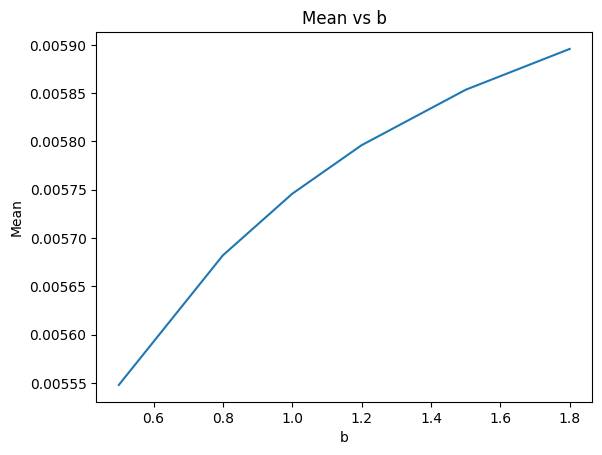

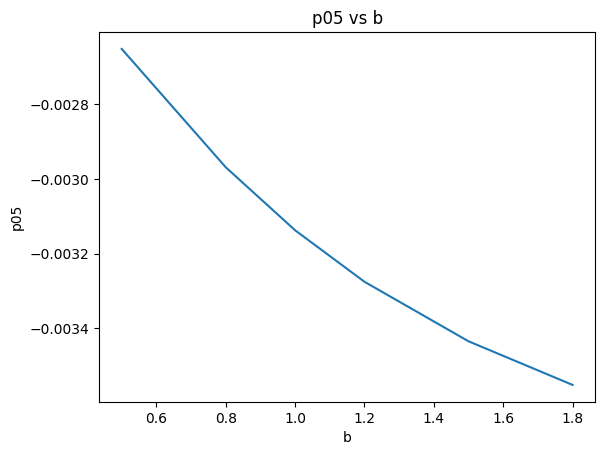

In [8]:
logistic_rows = summary[summary.index.str.startswith("logistic_b")]

b_extracted = (
    logistic_rows.index
    .str.extract(r'logistic_b(.*)')[0]
    .str.replace("p",".")
    .astype(float)
)

means = logistic_rows["mean"].values
p05_vals = logistic_rows["p05"].values

order = np.argsort(b_extracted.values)

b_sorted = b_extracted.values[order]
means_sorted = means[order]
p05_sorted = p05_vals[order]

plt.figure()
plt.plot(b_sorted, means_sorted)
plt.title("Mean vs b")
plt.xlabel("b")
plt.ylabel("Mean")
plt.show()

plt.figure()
plt.plot(b_sorted, p05_sorted)
plt.title("p05 vs b")
plt.xlabel("b")
plt.ylabel("p05")
plt.show()


In [15]:
phase2_mean = summary.loc["phase2_gate", "mean"]
target = 0.8 * phase2_mean

candidates = logistic_rows[logistic_rows["mean"] >= target].copy()

if len(candidates) > 0:
    best = candidates.sort_values(["p05","mean"], ascending=[False, False]).index[0]
    reason = f"meets mean≥{target:.6f} then best p05"
else:
    logistic_rows = logistic_rows.copy()
    logistic_rows["mean_gap"] = (target - logistic_rows["mean"]).abs()
    best = logistic_rows.sort_values(["mean_gap","p05"], ascending=[True, False]).index[0]
    reason = f"NO version meets mean≥{target:.6f}; picked closest-to-threshold"

print("Selected:", best)
print("Reason:", reason)
print("Selected stats:\n", summary.loc[best])


Selected: logistic_b1p8
Reason: NO version meets mean≥0.007932; picked closest-to-threshold
Selected stats:
 n       55.000000
mean     0.005896
vol      0.006952
p05     -0.003552
min     -0.006697
Name: logistic_b1p8, dtype: float64


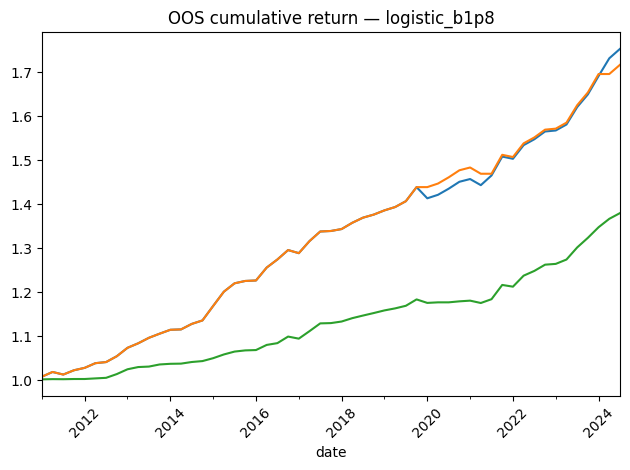

In [10]:
def cumprod_series(r):
    r = r.fillna(0)
    return (1 + r).cumprod()

oos_dates = df.loc[oos, "date"]

baseline = pd.Series(
    df.loc[oos, "strat_baseline"].values,
    index=oos_dates
)

phase2 = pd.Series(
    df.loc[oos, "strat_p2"].values,
    index=oos_dates
)

best_series = pd.Series(
    df.loc[oos, f"strat_{best}"].values,
    index=oos_dates
)

ax = cumprod_series(baseline).plot(
    title=f"OOS cumulative return — {best}"
)

cumprod_series(phase2).plot(ax=ax)
cumprod_series(best_series).plot(ax=ax)

plt.xticks(rotation=45)
plt.tight_layout()


In [12]:
for b in b_values:
    name = f"logistic_b{str(b).replace('.','p')}"
    print(name, df[f"exposure_{name}"].mean())


logistic_b0p5 0.5338319504638953
logistic_b0p8 0.5453695917154816
logistic_b1p0 0.5505669112977314
logistic_b1p2 0.5543893093122964
logistic_b1p5 0.5582917027735179
logistic_b1p8 0.5607108459763064


In [11]:
OUT_SERIES = "outputs/phase4/series/oos_series_v43_bgrid.csv"
OUT_SUMMARY = "outputs/phase4/tables/oos_summary_v43_bgrid.csv"

df.to_csv(OUT_SERIES, index=False)
summary.to_csv(OUT_SUMMARY)

print("Saved v43 outputs.")


Saved v43 outputs.


In [14]:
print("Signal range:", df[SIGNAL_COL].min(), df[SIGNAL_COL].max())

for b in b_values:
    name = f"logistic_b{str(b).replace('.','p')}"
    ex = df.loc[oos, f"exposure_{name}"]
    print(name, "exposure mean:", ex.mean(), "p05:", ex.quantile(0.05), "min:", ex.min())


Signal range: -4.82896076178271 4.90324210468478
logistic_b0p5 exposure mean: 0.5246198126075715 p05: 0.2939000107192732 min: 0.08207513889885598
logistic_b0p8 exposure mean: 0.5334544658571104 p05: 0.19757926211895618 min: 0.020569364510818745
logistic_b1p0 exposure mean: 0.537717270188115 p05: 0.14792655185258805 min: 0.007931415198053501
logistic_b1p2 exposure mean: 0.5410704333376838 p05: 0.10909612214356793 min: 0.003034247656103541
logistic_b1p5 exposure mean: 0.5448626095532267 p05: 0.06768109879010482 min: 0.0007143369880409313
logistic_b1p8 exposure mean: 0.547630617062615 p05: 0.04129006510077272 min: 0.000167873932970857
